# Validation & Test Set Construction

This notebook builds an **independent** validation and test benchmark for the
image-recognition models trained in notebook 06:

- the fine-tuned **ResNet-18 presentation-type classifier**
  (`models/resnet18_classifier_al.pth`, 7 classes:
  `bullet, closed, lips, liquid, pencil, swatch, unclassifiable`), and
- the per-type **U-Net colour-region segmenters**
  (`unet_segmenter`, `unet_segmenter_other`, `unet_swatch`, `unet_lips`).

**Why a separate benchmark is needed.** What notebook 06 calls "validation" is an
80/20 stratified split of the ~380 *training* annotations, and that same split is
reused for threshold tuning, model selection, and the active-learning loop. Every
accuracy / IoU / ΔE number reported so far is therefore a development-set estimate,
not a measure of generalisation. This notebook draws evaluation images from a pool
that never touched training, model selection, or active learning.

**Dependencies (data + methods, not a strict run-order):**

| From | What |
|---|---|
| notebooks 01–02 | the frame `data/processed/products_with_images.csv` |
| notebook 03 | `slugify` / `map_to_color_group` and the colour-group taxonomy |
| notebook 04 | the ground-truth-CIELAB method (`extract_cielab` on a cropped swatch) |
| notebook 05 | `data/processed/annotations_combined.csv` (training type labels) |
| notebook 06 | the model checkpoints, `data/annotations/labels.csv`, and the active-learning queues |
| raw | `data/product_metadata/product_lipstick_metadata.csv` for `date_added` (temporal split) |

**Three-part workflow**

- **Part A — sampling plan (runs now).** Derive statistically-grounded per-class
  sample sizes, build the held-out pool, split it temporally into validation and
  test candidates, run the classifier over the whole pool, draw a representative
  *core* sample plus classifier-assisted *boost* top-ups for rare types, and write
  one annotation worklist: `data/annotation_sample/eval_worklist.csv`.
- **Part B — ingestion (after annotation).** Parse the Label Studio export and the
  ground-truth swatch crops into `data/annotations/labels_val.csv` and
  `data/annotations/labels_test.csv`.
- **Part C — evaluation (after ingestion).** Report per-class classifier accuracy /
  false-positive / false-negative rates, segmentation IoU, and ΔE CIE 2000, each
  with a confidence interval.

Parts B and C are guarded: on the first run they print a "skipped" message and do
nothing, because the manual annotation artifacts do not exist yet.

## Design decisions

**1. Sample sizes are derived from statistics, not chosen by rule of thumb.**
For each metric we set a target margin of error and back out the required number of
examples with the standard sample-size formula (Cochran / normal approximation for a
proportion; mean-precision for a continuous metric), then apply a finite-population
correction against the held-out pool. This mirrors notebook 03's training-set sizing,
which used Cochran's formula with a prior CIELAB variance estimate. The per-class
floor is the **maximum** over the metrics that apply to that class; the set total is
the **sum** of the per-class floors.

**2. Classifier-assisted prioritisation, with the two blocks reported separately.**
A *core* block is drawn purely at random, stratified only by colour group — it
carries the headline metrics and is an unbiased sample of the held-out pool.
A *boost* block adds extra images for any class whose count in the core sample
falls below its statistical floor — in practice the rare types (`lips`, `pencil`,
`closed`, `unclassifiable`). Boost images are the ones the notebook-06 classifier
most confidently *predicts* are that class. Because that selection uses the
classifier's own prediction, the class's apparent routing recall is optimistically
biased in the boost block, so boost rows are always tabulated on their own and
never folded into the headline numbers.

**3. The test set is a temporal split.** Products added on or after a tunable cutoff
date form the test candidate pool; everything else (added earlier, or with no
recorded date) is validation. This measures performance on genuinely newer products,
which is the real production scenario. Caveats: only ~63% of pool images carry a
usable `date_added`, so undated images are validation-only by construction and the
temporal boundary is soft; and a small number of training images post-date the
cutoff — that leakage is measured and reported below.

In [1]:
import os
import re
import json
import glob
import warnings
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats
from skimage.color import rgb2lab
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# colormath needs a numpy attribute removed in newer numpy — restore it before import
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda a: a.item()
from colormath.color_objects import LabColor
from colormath.color_diff import delta_e_cie2000

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available()
          else 'cpu')

# Notebook runs from notebooks/ ; paths mirror notebooks 03 / 04
BASE       = os.path.abspath('../data')
DATA       = os.path.join(BASE, 'processed')
RAW        = os.path.join(BASE, 'product_metadata')
ANN_DIR    = os.path.join(BASE, 'annotations')
ANN_SAM    = os.path.join(BASE, 'annotation_sample')
MASKS_DIR  = os.path.join(ANN_DIR, 'masks')
CLEAN      = os.path.join(BASE, 'img', 'original_clean')
IMGS_GT    = os.path.join(BASE, 'img', 'groundtruth')
MODELS_DIR = os.path.abspath('../models')

for d in (ANN_SAM, ANN_DIR, MASKS_DIR):
    os.makedirs(d, exist_ok=True)

print(f'device: {DEVICE}  |  seed: {SEED}')


def slugify(text):
    """Lowercase, accent-stripped, underscore-joined slug (from notebook 03)."""
    if pd.isna(text):
        return ''
    text = str(text).lower().strip()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', '_', text.strip())
    return text


def map_to_color_group(color):
    """Map a raw parent_color string to one of the 18 canonical colour groups
    (verbatim from notebook 03 — kept here so notebook 11 is self-contained and
    can regenerate color_group if the frame lacks it)."""
    if pd.isna(color):
        return 'no_color_info'
    c = str(color).lower().strip()
    if any(k in c for k in ['fuchsia', 'magenta', 'violet', 'purple', 'lilac', 'amethyst', 'orchid', 'lavender']):
        return 'purple_fuchsia'
    if any(k in c for k in ['pink nude', 'nude pink', 'pink beige', 'beige pink', 'pink brown nude', 'brown nude pink', 'gray pink nude', 'blush nude', 'blush pink']):
        return 'pink_nude'
    if any(k in c for k in ['berry', 'plum', 'burgundy', 'wine', 'cherry', 'blackberry', 'raspberry', 'raisin', 'cranberry', 'mulberry', 'sangria', 'merlot', 'cabernet', 'claret', 'currant', 'oxblood', 'maroon', 'boysenberry', 'pomegranate', 'prune', 'fig', 'aubergine', 'eggplant', 'garnet', 'marsala', 'bordeaux', 'grape']):
        return 'berry_plum'
    if any(k in c for k in ['brick']):
        return 'brick'
    if any(k in c for k in ['coral']):
        return 'coral'
    if any(k in c for k in ['orange', 'terracotta', 'pumpkin', 'rust', 'tangerine', 'persimmon', 'papaya', 'amber', 'apricot', 'ginger', 'saffron', 'cayenne', 'copper', 'vermilion', 'carrot', 'squash', 'clementine', 'melon', 'guava', 'grapefruit', 'ochre']):
        return 'orange'
    if any(k in c for k in ['peach']):
        return 'peach'
    if any(k in c for k in ['mauve']):
        return 'mauve'
    if any(k in c for k in ['rose', 'rosewood', 'rosewater', 'rosebud']):
        return 'rose'
    if any(k in c for k in ['brown', 'mocha', 'chocolate', 'cocoa', 'coffee', 'caramel', 'chestnut', 'hazelnut', 'toffee', 'espresso', 'sepia', 'mahogany', 'walnut', 'brunette', 'brandy', 'cognac', 'taupe', 'sienna', 'umber', 'tawny', 'truffle', 'sable', 'saddle', 'russet', 'malt', 'maple', 'cedar', 'chai', 'cinnamon', 'nutmeg', 'gingerbread', 'nougat', 'butterscotch', 'cashew', 'pecan', 'almond', 'fawn', 'buff', 'camel', 'mushroom', 'greige', 'griege', 'clay', 'auburn', 'pebble', 'corduroy', 'wood', 'rusk', 'redwood', 'desert']):
        return 'brown'
    if any(k in c for k in ['red', 'scarlet', 'crimson', 'ruby', 'tomato', 'poppy', 'geranium', 'hibiscus', 'cerise', 'apple']):
        return 'red'
    if any(k in c for k in ['pink', 'bubblegum', 'blush', 'petal', 'blossom', 'carnation', 'peony', 'salmon']):
        return 'pink'
    if any(k in c for k in ['nude', 'beige', 'clear', 'latte', 'champagne', 'sand', 'ivory', 'honey', 'ecru', 'biscuit', 'spice', 'tan']):
        return 'nude_beige'
    if any(k in c for k in ['gold', 'golden', 'bronze', 'yellow']):
        return 'gold_bronze'
    if any(k in c for k in ['black', 'ebony', 'charcoal', 'charcol']):
        return 'black'
    if any(k in c for k in ['blue', 'cobalt', 'navy', 'teal', 'turquoise', 'green', 'denim', 'indigo', 'spearmint', 'peacock', 'topaz']):
        return 'blue_green'
    if any(k in c for k in ['gray', 'grey', 'silver', 'white', 'gunmetal']):
        return 'silver_gray'
    return 'other'

device: mps  |  seed: 42


## Part A — Sampling plan

### A1. Statistical sample-size framework

For a **proportion** metric $p$ (classifier accuracy, per-class error rate,
false-positive rate, false-negative rate) the normal-approximation / Cochran
sample size for a two-sided $100(1-\alpha)\%$ interval of half-width $e$ is

$$ n_0 = \frac{z_{\alpha/2}^{2}\; \hat p\,(1-\hat p)}{e^{2}} $$

For a **continuous** metric with prior standard deviation $\sigma$ (segmentation
IoU, ΔE CIE 2000) the mean-precision sample size is

$$ n_0 = \frac{z_{\alpha/2}^{2}\; \sigma^{2}}{e^{2}} $$

Both are corrected for the finite pool of $N$ eligible images of that class:

$$ n = \frac{n_0}{1 + (n_0 - 1)/N} $$

We use $z_{\alpha/2}=1.96$ (95%). At report time proportions get a **Wilson score
interval** (better small-sample coverage than the Wald interval) and means get a
**Student-$t$ interval**.

**Which metric applies to which class**

| metric | classes it applies to |
|---|---|
| classifier accuracy / FP / FN | all 7 |
| segmentation IoU | `bullet`, `liquid`, `pencil`, `closed`, `swatch` (classes with a segmenter) |
| ΔE CIE 2000 | all except `unclassifiable` (no colour to extract) |

Per-class floor = max of the applicable $n$; set total = sum of per-class floors.
The `SCENARIO` switch below toggles between the strict `target` margins and a
budget-`relaxed` set (roughly half the annotation volume).

In [2]:
# ── tunables ────────────────────────────────────────────────────────────────
SCENARIO = 'target'          # 'target' or 'relaxed'
Z = 1.96                     # 95% two-sided

TARGET_MOE = {
    'target':  {'accuracy': 0.10, 'fn_rate': 0.10, 'fp_rate': 0.08, 'iou': 0.05, 'delta_e': 1.0},
    'relaxed': {'accuracy': 0.15, 'fn_rate': 0.15, 'fp_rate': 0.12, 'iou': 0.10, 'delta_e': 1.5},
}[SCENARIO]

# ── priors (each cites where in the repo the estimate comes from) ────────────
# p-hat for accuracy is deliberately conservative: notebook 06's per-class recall
# ranges 0.83–1.00 on tiny support, and p=1 -> n0=0, so we floor it at 0.85.
priors = pd.DataFrame([
    {'metric': 'accuracy', 'kind': 'proportion', 'estimate': 0.85,
     'source': 'nb06 cell 15/57 classification_report, per-class recall floored at 0.85'},
    {'metric': 'fn_rate',  'kind': 'proportion', 'estimate': 0.15,
     'source': 'nb06 cell 15 confusion matrix (bullet FN ~0.13, others lower)'},
    {'metric': 'fp_rate',  'kind': 'proportion', 'estimate': 0.10,
     'source': 'nb06 cell 15 confusion matrix off-diagonal column mass'},
    {'metric': 'iou',      'kind': 'mean',       'estimate': 0.20,
     'source': 'nb06 cell 34 per-class IoU spread 0.13-0.93; 0.20 ~ pooled within-class SD'},
    {'metric': 'delta_e',  'kind': 'mean',       'estimate': 3.0,
     'source': 'nb06 cell 46 median-strategy IQR (~2.3 overall, ~3.4 bullet/liquid) + right tail'},
])
priors['e'] = priors['metric'].map(TARGET_MOE)


def n0_proportion(p, e, z=Z):
    return z ** 2 * p * (1.0 - p) / e ** 2


def n0_mean(sigma, e, z=Z):
    return z ** 2 * sigma ** 2 / e ** 2


def fpc(n0, N):
    """Finite population correction against a pool of size N."""
    if N is None or N <= 0:
        return n0
    return n0 / (1.0 + (n0 - 1.0) / N)


priors['n0'] = priors.apply(
    lambda r: n0_proportion(r['estimate'], r['e']) if r['kind'] == 'proportion'
    else n0_mean(r['estimate'], r['e']),
    axis=1,
).round(1)

METRIC_CLASSES = {
    'accuracy': 'all', 'fn_rate': 'all', 'fp_rate': 'all',
    'iou': ['bullet', 'liquid', 'pencil', 'closed', 'swatch'],
    'delta_e': ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch'],
}

print(f'SCENARIO = {SCENARIO}   (z = {Z})\n')
print(priors[['metric', 'kind', 'estimate', 'e', 'n0', 'source']].to_string(index=False))
print(f'\nPopulation-independent driver: n0 = {priors["n0"].max():.0f} '
      f'({priors.loc[priors["n0"].idxmax(), "metric"]})')

SCENARIO = target   (z = 1.96)

  metric       kind  estimate    e   n0                                                                           source
accuracy proportion      0.85 0.10 49.0          nb06 cell 15/57 classification_report, per-class recall floored at 0.85
 fn_rate proportion      0.15 0.10 49.0                    nb06 cell 15 confusion matrix (bullet FN ~0.13, others lower)
 fp_rate proportion      0.10 0.08 54.0                           nb06 cell 15 confusion matrix off-diagonal column mass
     iou       mean      0.20 0.05 61.5       nb06 cell 34 per-class IoU spread 0.13-0.93; 0.20 ~ pooled within-class SD
 delta_e       mean      3.00 1.00 34.6 nb06 cell 46 median-strategy IQR (~2.3 overall, ~3.4 bullet/liquid) + right tail

Population-independent driver: n0 = 62 (iou)


### A2. Held-out pool

The pool is the frame minus every image that has already been seen by training,
model selection, or active learning, minus corrupted or missing files:

`pool = frame − annotations_combined − labels − s1/s2/s4 annotation samples −
annotation_sample.csv − active-learning queues − pending-lips list − corrupted`

Names are matched on a normalised stem — file extension stripped, plus the 7-char
Label-Studio dedup suffix (`_XXXXXXX`) stripped — so `labels.csv`-style names line
up with frame stems.

In [3]:
frame = pd.read_csv(os.path.join(DATA, 'products_with_images.csv'), low_memory=False)
frame = frame[frame['img_name'].apply(lambda x: isinstance(x, str) and '.' in x)].copy()

# colour group: present on disk, but regenerate defensively if missing
if 'color_group' not in frame.columns:
    if 'parent_color' not in frame.columns:
        _raw = pd.read_csv(os.path.join(RAW, 'product_lipstick_metadata.csv'), low_memory=False)
        _raw['id'] = (_raw['category'].apply(slugify) + '__' + _raw['brand'].apply(slugify)
                      + '__' + _raw['product'].apply(slugify) + '__' + _raw['shade'].apply(slugify))
        _raw = _raw.drop_duplicates('id', keep='first')
        frame = frame.merge(_raw[['id', 'parent_color']], on='id', how='left')
    frame['color_group'] = frame['parent_color'].apply(map_to_color_group)

frame['img_name_disk'] = frame['img_name'].apply(lambda n: os.path.splitext(str(n))[0] + '.jpg')
frame['stem'] = frame['img_name_disk'].str[:-4]


def normalize_stem(s):
    s = re.sub(r'\.(jpg|jpeg|png|webp|tif|gif)$', '', str(s), flags=re.I)
    s = re.sub(r'_[A-Za-z0-9]{7}$', '', s)
    return s


# every CSV / list that marks an image as "already used" — read via a loop so the
# notebook-lint CSV-producer check does not fire on these non-producer files
EXCLUSION_SOURCES = [
    (os.path.join(DATA, 'annotations_combined.csv'), 'img_name'),
    (os.path.join(DATA, 'annotation_sample.csv'), 'img_name'),
    (os.path.join(ANN_DIR, 'labels.csv'), 'img_name'),
    (os.path.join(ANN_SAM, 's1_color_taxonomy.csv'), 'img_name'),
    (os.path.join(ANN_SAM, 's2_style_discovery.csv'), 'img_name'),
    (os.path.join(ANN_SAM, 's3_closed_containers.csv'), 'img_name'),
    (os.path.join(ANN_SAM, 's4_pencil_crayon.csv'), 'img_name'),
    (os.path.join(ANN_DIR, 'active_learning_queue.csv'), 'img_name'),
    (os.path.join(ANN_DIR, 'active_learning_2nd_queue.csv'), 'img_name'),
    (os.path.join(ANN_DIR, 'active_learning_seg_queue.csv'), 'img_name'),
]

exclusion = set()
for path, col in EXCLUSION_SOURCES:
    if not os.path.exists(path):
        continue
    t = pd.read_csv(path)
    if col not in t.columns:
        continue
    exclusion |= {normalize_stem(x) for x in t[col].dropna()}

# the 17 staged-but-unannotated lips / colour-not-shown images
_pending = os.path.join(ANN_DIR, 'lips_notshown_pending.txt')
if os.path.exists(_pending):
    with open(_pending) as f:
        exclusion |= {normalize_stem(ln.strip()) for ln in f if ln.strip().startswith('lipstick__')}

print(f'{len(exclusion)} unique training-touched stems')

630 unique training-touched stems


In [4]:
frame['in_training'] = frame['stem'].apply(normalize_stem).isin(exclusion)
frame['on_disk'] = frame['img_name_disk'].apply(lambda f: os.path.exists(os.path.join(CLEAN, f)))
frame['img_corrupted'] = frame.get('img_corrupted', pd.Series(False, index=frame.index)).fillna(False)

pool = frame[~frame['in_training'] & ~frame['img_corrupted'] & frame['on_disk']].copy()

print(f'frame rows (with image)      : {len(frame)}')
print(f'  in training / selection    : {frame["in_training"].sum()}')
print(f'  corrupted                  : {int(frame["img_corrupted"].sum())}')
print(f'  missing from original_clean : {(~frame["on_disk"]).sum()}')
print(f'held-out pool                 : {len(pool)}')

assert not pool['stem'].apply(normalize_stem).isin(exclusion).any(), 'pool leaks a training image'

print('\npool colour-group distribution:')
print(pool['color_group'].value_counts().to_string())

frame rows (with image)      : 9167
  in training / selection    : 633
  corrupted                  : 1
  missing from original_clean : 0
held-out pool                 : 8533

pool colour-group distribution:
color_group
no_color_info     2833
berry_plum         827
brown              654
red                626
rose               588
pink               527
mauve              405
nude_beige         397
orange             336
purple_fuchsia     331
pink_nude          300
peach              279
coral              262
brick              122
gold_bronze         17
black               15
blue_green          13
silver_gray          1


### A3. Temporal split

`date_added` is not in the frame — it lives only in the raw retailer metadata, so
we merge it back on the `joined` key. Dates are parsed leniently and obviously
wrong years (before 2020 or after 2026) are dropped. The cutoff `CUTOFF` is a
tunable; images added on/after it (and not already in training) are **test**
candidates, everything else is **validation** candidates.

The contamination figure printed below is the number of *training* images that
also fall after the cutoff — unavoidable leakage into the temporal test regime,
reported for honesty.

CUTOFF = 2024-06-01
pool date coverage      : 60.1%  (5131/8533)
test candidates (>= cut) : 1189
val candidates           : 7344   (pre-cutoff 3942 + undated 3402)
training images post-cut : 74   <-- temporal leakage, reported


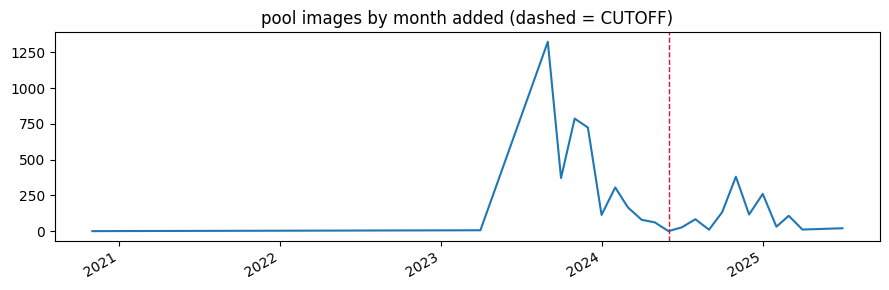

In [5]:
CUTOFF = pd.Timestamp('2024-06-01')       # tunable: start of the held-out "recent" period

_raw = pd.read_csv(os.path.join(RAW, 'product_lipstick_metadata.csv'), low_memory=False)
_raw_dates = _raw.drop_duplicates('joined')[['joined', 'date_added', 'launch_year']]
pool = pool.merge(_raw_dates, on='joined', how='left')

_d = pd.to_datetime(pool['date_added'], format='mixed', errors='coerce')
_d = _d.mask((_d.dt.year < 2020) | (_d.dt.year > 2026))
pool['date_parsed'] = _d
pool['has_date'] = pool['date_parsed'].notna()
pool['is_post_cutoff'] = pool['has_date'] & (pool['date_parsed'] >= CUTOFF)

test_candidates = pool[pool['is_post_cutoff']].copy()
val_candidates = pool[~pool['is_post_cutoff']].copy()

# contamination: training images that post-date the cutoff
_train = frame[frame['in_training']].merge(_raw_dates, on='joined', how='left')
_td = pd.to_datetime(_train['date_added'], format='mixed', errors='coerce')
_td = _td.mask((_td.dt.year < 2020) | (_td.dt.year > 2026))
n_contam = int((_td >= CUTOFF).sum())

print(f'CUTOFF = {CUTOFF.date()}')
print(f'pool date coverage      : {pool["has_date"].mean() * 100:.1f}%  ({pool["has_date"].sum()}/{len(pool)})')
print(f'test candidates (>= cut) : {len(test_candidates)}')
print(f'val candidates           : {len(val_candidates)}   (pre-cutoff {int((val_candidates["has_date"]).sum())} + undated {int((~val_candidates["has_date"]).sum())})')
print(f'training images post-cut : {n_contam}   <-- temporal leakage, reported')

fig, ax = plt.subplots(figsize=(9, 3))
pool.loc[pool['has_date'], 'date_parsed'].dt.to_period('M').dt.to_timestamp().value_counts().sort_index().plot(ax=ax)
ax.axvline(CUTOFF, color='crimson', ls='--', lw=1)
ax.set_title('pool images by month added (dashed = CUTOFF)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

### A4. Classifier pass over the pool

We run the notebook-06 classifier over **every** pool image to get a predicted
type. The *core* sample ignores these predictions entirely; the *boost* block uses
them to surface candidates for the under-represented types. This is ~8–9k forward
passes — about a minute on an MPS laptop GPU, a few minutes on CPU.

In [6]:
IMG_SIZE_CLS = 224
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def find_image(img_name, img_dirs=(CLEAN,)):
    for d in img_dirs:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None


def resolve_img_name(img_name, img_dirs=(CLEAN,)):
    """Map a Label-Studio img_name to the actual file on disk (strip a 7-char
    dedup suffix if needed). From notebook 06."""
    if find_image(img_name, img_dirs) is not None:
        return img_name
    base = re.sub(r'_[A-Za-z0-9]{7}(\.jpg)$', r'\1', img_name)
    if base != img_name and find_image(base, img_dirs) is not None:
        return base
    return None


def build_classifier(num_classes, pretrained=False):
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


def score_clf_uncertainty(model, img_path, device, class_names):
    """Return (predicted_class, confidence, full_softmax_probs). From notebook 06."""
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(model(val_tf(img).unsqueeze(0).to(device)), dim=1).squeeze().cpu().numpy()
    return class_names[int(probs.argmax())], float(probs.max()), probs


CLF_THRESHOLD = 0.6
_ckpt = torch.load(os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth'), map_location=DEVICE)
classes = list(_ckpt['classes'])
assert classes == sorted(classes) and len(classes) == 7, classes

clf = build_classifier(len(classes)).to(DEVICE)
clf.load_state_dict(_ckpt['model_state_dict'])
clf.eval()
print(f'classifier loaded — classes: {classes}')

classifier loaded — classes: ['bullet', 'closed', 'lips', 'liquid', 'pencil', 'swatch', 'unclassifiable']


In [7]:
class _PoolDataset(Dataset):
    def __init__(self, names):
        self.names = list(names)

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        name = self.names[i]
        img = Image.open(os.path.join(CLEAN, name)).convert('RGB')
        return val_tf(img), i


_names = pool['img_name_disk'].tolist()
_probs = np.zeros((len(_names), len(classes)), dtype=np.float32)
_loader = DataLoader(_PoolDataset(_names), batch_size=64, num_workers=0)

clf.eval()
with torch.no_grad():
    for xb, idx in _loader:
        p = torch.softmax(clf(xb.to(DEVICE)), dim=1).cpu().numpy()
        _probs[idx.numpy()] = p

pred_df = pd.DataFrame(_probs, columns=[f'p_{c}' for c in classes])
pred_df['img_name_disk'] = _names
pred_df['pred_label'] = [classes[k] for k in _probs.argmax(1)]
pred_df['confidence'] = _probs.max(1)

pool = pool.merge(pred_df, on='img_name_disk', how='left')
val_candidates = val_candidates.merge(pred_df, on='img_name_disk', how='left')
test_candidates = test_candidates.merge(pred_df, on='img_name_disk', how='left')

print('predicted-label distribution over the pool:')
print(pool['pred_label'].value_counts().to_string())
print('\npredicted label x split:')
print(pd.crosstab(pool['pred_label'], np.where(pool['is_post_cutoff'], 'test', 'val')).to_string())

predicted-label distribution over the pool:
pred_label
swatch            3513
bullet            2877
liquid            1389
closed             261
pencil             227
unclassifiable     191
lips                75

predicted label x split:
col_0           test   val
pred_label                
bullet           367  2510
closed            17   244
lips              16    59
liquid           181  1208
pencil            26   201
swatch           551  2962
unclassifiable    31   160


In [8]:
def per_class_floor(class_name, N_pool):
    """max over applicable metrics of the FPC-corrected sample size."""
    reqs = []
    for _, r in priors.iterrows():
        scope = METRIC_CLASSES[r['metric']]
        if scope != 'all' and class_name not in scope:
            continue
        reqs.append(fpc(r['n0'], N_pool))
    return int(np.ceil(max(reqs))) if reqs else 0


rows = []
for c in classes:
    n_val_pool = int((val_candidates['pred_label'] == c).sum())
    n_test_pool = int((test_candidates['pred_label'] == c).sum())
    rows.append({
        'class': c,
        'N_val_pool': n_val_pool,
        'n_val_floor': per_class_floor(c, n_val_pool),
        'N_test_pool': n_test_pool,
        'n_test_floor': per_class_floor(c, n_test_pool),
    })
floors_df = pd.DataFrame(rows).set_index('class')
floors_df['val_short'] = (floors_df['n_val_floor'] > floors_df['N_val_pool'])
floors_df['test_short'] = (floors_df['n_test_floor'] > floors_df['N_test_pool'])

N_VAL_CORE = int(floors_df['n_val_floor'].sum())
N_TEST_CORE = int(floors_df['n_test_floor'].sum())

print(floors_df.to_string())
print(f'\ncore targets  ->  val {N_VAL_CORE}   test {N_TEST_CORE}')
if floors_df['test_short'].any():
    print('shortfall (test pool cannot meet the floor for): '
          + ', '.join(floors_df.index[floors_df['test_short']]))

                N_val_pool  n_val_floor  N_test_pool  n_test_floor  val_short  test_short
class                                                                                    
bullet                2510           61          367            53      False       False
closed                 244           50           17            14      False       False
lips                    59           29           16            13      False       False
liquid                1208           59          181            47      False       False
pencil                 201           48           26            19      False       False
swatch                2962           61          551            56      False       False
unclassifiable         160           41           31            20      False       False

core targets  ->  val 349   test 222


In [9]:
def draw_core(cand_df, n_total, seed=SEED):
    """Random sample stratified by colour group, proportional to the candidate
    pool (representative — no per-class floor). Returns a copy tagged block='core'."""
    if n_total >= len(cand_df):
        out = cand_df.copy()
    else:
        share = cand_df['color_group'].value_counts(normalize=True)
        alloc = (share * n_total).round().astype(int).clip(lower=0)
        out = (cand_df.groupby('color_group', group_keys=False)
               .apply(lambda g: g.sample(n=min(int(alloc.get(g.name, 0)), len(g)), random_state=seed)))
    out = out.copy()
    out['block'] = 'core'
    return out


val_core = draw_core(val_candidates, N_VAL_CORE)
test_core = draw_core(test_candidates, N_TEST_CORE)

print(f'val_core  {len(val_core)}   test_core {len(test_core)}')
print('\nval_core predicted-label vs floor:')
_vc = val_core['pred_label'].value_counts()
print(pd.DataFrame({'core_pred': _vc, 'floor': floors_df['n_val_floor']}).fillna(0).astype(int).to_string())

val_core  350   test_core 221

val_core predicted-label vs floor:
                core_pred  floor
bullet                126     61
closed                 12     50
lips                    1     29
liquid                 51     59
pencil                  7     48
swatch                143     61
unclassifiable         10     41


In [10]:
# Any class whose representative *core* count falls below its statistical floor is
# topped up here (in practice the rare types: lips, pencil, closed, unclassifiable,
# sometimes liquid). Selection is on the classifier's PREDICTED label, most-confident
# first — which biases that class's apparent routing recall, so boost rows are always
# reported on their own and never folded into the headline (core) numbers.
BOOST_CLASSES = list(classes)


def draw_boost(cand_df, core_df, floor_col, seed=SEED):
    have = set(core_df['img_name_disk'])
    picks = []
    for c in BOOST_CLASSES:
        core_n = int((core_df['pred_label'] == c).sum())
        need = max(0, int(floors_df.loc[c, floor_col]) - core_n)
        if need == 0:
            continue
        avail = (cand_df[(cand_df['pred_label'] == c) & (~cand_df['img_name_disk'].isin(have))]
                 .sort_values('confidence', ascending=False)
                 .head(need)
                 .copy())
        avail['block'] = 'boost'
        avail['priority'] = range(1, len(avail) + 1)
        picks.append(avail)
    if not picks:
        empty = cand_df.iloc[0:0].copy()
        empty['block'] = pd.Series(dtype=object)
        empty['priority'] = pd.Series(dtype=int)
        return empty
    return pd.concat(picks, ignore_index=True)


val_boost = draw_boost(val_candidates, val_core, 'n_val_floor')
test_boost = draw_boost(test_candidates, test_core, 'n_test_floor')

print('boost rows added (val):')
print(val_boost['pred_label'].value_counts().to_string() if len(val_boost) else '  none')
print('\nboost rows added (test):')
print(test_boost['pred_label'].value_counts().to_string() if len(test_boost) else '  none')
print('\nNOTE: boost rows are selected on the classifier\'s own prediction, so their '
      'routing recall is optimistically biased — reported separately in Part C.')

boost rows added (val):
pred_label
pencil            41
closed            38
unclassifiable    31
lips              28
liquid             8

boost rows added (test):
pred_label
unclassifiable    16
pencil            14
closed            12
lips               9
liquid             6

NOTE: boost rows are selected on the classifier's own prediction, so their routing recall is optimistically biased — reported separately in Part C.


In [11]:
WORKLIST_COLS = [
    'img_name_disk', 'id', 'joined', 'brand', 'product', 'shade',
    'color_group', 'parent_color', 'split', 'block', 'priority',
    'pred_label', 'confidence', 'date_added', 'date_parsed', 'is_post_cutoff',
    'needs_mask', 'needs_groundtruth_crop',
]


def _prep(df, split):
    df = df.copy()
    df['split'] = split
    if 'priority' not in df.columns:
        df['priority'] = np.nan
    return df


parts = [_prep(val_core, 'val'), _prep(val_boost, 'val'),
         _prep(test_core, 'test'), _prep(test_boost, 'test')]
worklist = pd.concat(parts, ignore_index=True)
worklist = worklist.drop_duplicates('img_name_disk', keep='first')

for c in ('parent_color', 'date_added'):
    if c not in worklist.columns:
        worklist[c] = np.nan
worklist['needs_mask'] = worklist['pred_label'] != 'unclassifiable'
worklist['needs_groundtruth_crop'] = worklist['pred_label'] != 'unclassifiable'

# annotation order: core rows shuffled within (split, colour group); boost rows
# keep their confidence rank, numbered after the core block
core_mask = worklist['block'] == 'core'
worklist.loc[core_mask, 'priority'] = (
    worklist[core_mask].groupby(['split', 'color_group']).cumcount() + 1
)
_core_max = worklist.loc[core_mask, 'priority'].max()
worklist.loc[~core_mask, 'priority'] = worklist.loc[~core_mask, 'priority'] + (_core_max or 0)
worklist['priority'] = worklist['priority'].astype(int)

worklist = worklist[WORKLIST_COLS].sort_values(['split', 'block', 'priority']).reset_index(drop=True)

assert worklist['img_name_disk'].is_unique
assert set(worklist[worklist['split'] == 'val']['img_name_disk']).isdisjoint(
    worklist[worklist['split'] == 'test']['img_name_disk'])

worklist.to_csv(os.path.join(ANN_SAM, 'eval_worklist.csv'), index=False)
print(f'wrote eval_worklist.csv  ({len(worklist)} rows)\n')
print(pd.crosstab(worklist['split'], worklist['block']).to_string())
print('\nby split x predicted label:')
print(pd.crosstab(worklist['split'], worklist['pred_label']).to_string())

wrote eval_worklist.csv  (774 rows)

block  boost  core
split             
test      57   221
val      146   350

by split x predicted label:
pred_label  bullet  closed  lips  liquid  pencil  swatch  unclassifiable
split                                                                   
test            67      14    13      47      19      98              20
val            126      50    29      59      48     143              41


### A. Caveats to carry into evaluation

- **Soft temporal boundary.** ~37% of pool images have no `date_added` and are
  validation-only by construction, so the test set is "recent *dated* products",
  not "all products after date X".
- **Temporal leakage.** A handful of training images post-date the cutoff (the
  contamination count printed in A3).
- **Boost recall bias.** Boost images (the rare types — typically `lips`, `pencil`,
  `closed`, `unclassifiable`) were chosen because the classifier *predicted* that
  class, so its apparent routing recall is optimistic there. Headline routing
  metrics in Part C use `block == 'core'` only.
- **ΔE coverage.** ΔE is computed only for images that get a manual ground-truth
  swatch crop; `unclassifiable` and no-visible-colour images are excluded by design.
- **Thin segmenter support.** `closed`, `lips`, and `pencil` have no dedicated
  segmenter data floor in notebook 06, so their IoU intervals will be wide even at
  the target sample size.

## Part B — Ingestion (run after annotation)

Annotate `eval_worklist.csv` in Label Studio:

1. one **presentation-type label** from the 7 classes;
2. a **brush mask** over the colour region for every image except `unclassifiable`
   (yes, including `swatch` — it has its own segmenter);
3. for every colour-bearing image, a **manually cropped ground-truth swatch** saved
   to `data/img/groundtruth/<stem>.jpg` — same method as notebook 04.

Export the Label Studio project JSON to `data/processed/eval_labelstudio.json`
(or a `project-*-eval-*.json` file). The cells below stay inert until that export
and the crops exist.

In [12]:
from label_studio_converter.brush import decode_rle as _ls_decode_rle


def decode_rle(rle, height, width):
    """Label-Studio brush RLE -> binary mask (H x W uint8). From notebook 06."""
    flat = _ls_decode_rle(rle)
    rgba = np.array(flat).reshape(height, width, 4)
    return (rgba[:, :, 3] > 0).astype(np.uint8)


def extract_cielab(img_name):
    """Mean CIELAB over a cropped ground-truth swatch in IMGS_GT. From notebook 04.
    Returns np.array([L, a, b]) or None if there is no crop for this stem."""
    stem = os.path.splitext(img_name)[0]
    matches = glob.glob(os.path.join(IMGS_GT, stem + '.*'))
    if not matches:
        return None
    swatch = cv2.cvtColor(cv2.imread(matches[0]), cv2.COLOR_BGR2RGB) / 255.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        lab = rgb2lab(swatch)
    return lab.mean(axis=0).mean(axis=0)


_export_candidates = ([os.path.join(DATA, 'eval_labelstudio.json')]
                      + sorted(glob.glob(os.path.join(DATA, 'project-*eval*.json'))))
EVAL_EXPORT = next((p for p in _export_candidates if os.path.exists(p)), _export_candidates[0])

worklist = pd.read_csv(os.path.join(ANN_SAM, 'eval_worklist.csv'))
print(f'worklist rows: {len(worklist)}')
print(f'looking for Label Studio export at: {EVAL_EXPORT}  '
      f'({"found" if os.path.exists(EVAL_EXPORT) else "not found yet"})')

worklist rows: 774
looking for Label Studio export at: /Users/connie/dev/lipstick_color_extraction/data/processed/eval_labelstudio.json  (not found yet)


In [13]:
LABEL_REMAP = {'multi_impage': 'unclassifiable', 'color_not_shown': 'unclassifiable'}

if not os.path.exists(EVAL_EXPORT):
    print(f'{EVAL_EXPORT} not found — Part B skipped. Annotate the worklist, export, re-run.')
    ls_labels = None
else:
    with open(EVAL_EXPORT) as f:
        raw = json.load(f)
    recs = []
    for task in raw:
        img_name = os.path.basename(task['data']['image'])
        img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name
        anns = task.get('annotations') or []
        if not anns or not anns[0].get('result'):
            continue
        res = anns[0]['result']
        brush = next((r for r in res if r['value'].get('rle')), None)
        label = None
        for r in res:
            v = r['value']
            if v.get('brushlabels'):
                label = v['brushlabels'][0]
            elif v.get('choices'):
                label = v['choices'][0]
        if label is None:
            continue
        label = LABEL_REMAP.get(label, label)
        disk = resolve_img_name(os.path.splitext(img_name)[0] + '.jpg') or (os.path.splitext(img_name)[0] + '.jpg')
        mask_path = os.path.join(MASKS_DIR, os.path.splitext(disk)[0] + '.png')
        if brush is not None:
            h = brush.get('original_height') or brush.get('value', {}).get('original_height')
            w = brush.get('original_width') or brush.get('value', {}).get('original_width')
            if h and w:
                m = decode_rle(brush['value']['rle'], int(h), int(w))
                Image.fromarray(m * 255).save(mask_path)
        recs.append({'img_name': img_name, 'img_name_disk': disk, 'label': label,
                     'mask_path': mask_path if brush is not None else np.nan})
    ls_labels = pd.DataFrame(recs)
    ls_labels = ls_labels.merge(worklist[['img_name_disk', 'split', 'block']], on='img_name_disk', how='left')
    _unknown = ls_labels['split'].isna().sum()
    if _unknown:
        print(f'warning: {_unknown} annotated images are not in the worklist — dropped')
        ls_labels = ls_labels[ls_labels['split'].notna()].copy()
    print(f'{len(ls_labels)} eval annotations parsed')
    print(ls_labels.groupby(['split', 'label']).size().to_string())

/Users/connie/dev/lipstick_color_extraction/data/processed/eval_labelstudio.json not found — Part B skipped. Annotate the worklist, export, re-run.


In [14]:
if ls_labels is None:
    print('Part B skipped — no annotations yet.')
else:
    def _lab(n):
        v = extract_cielab(n)
        return pd.Series([np.nan] * 3 if v is None else list(v), index=['true_L', 'true_a', 'true_b'])

    ls_labels = pd.concat([ls_labels, ls_labels['img_name_disk'].apply(_lab)], axis=1)
    _cov = ls_labels['true_L'].notna().sum()
    print(f'ground-truth CIELAB crops found: {_cov} / {len(ls_labels)}')
    print('  (missing crops just leave ΔE undefined for that image)')

Part B skipped — no annotations yet.


In [15]:
LABELS_SCHEMA = ['img_name', 'label', 'img_name_disk', 'true_L', 'true_a', 'true_b', 'mask_path', 'split', 'block']

if ls_labels is None:
    labels_val_df = labels_test_df = None
    print('Part B skipped — labels_val.csv / labels_test.csv not written.')
else:
    out = ls_labels.reindex(columns=LABELS_SCHEMA)
    labels_val_df = out[out['split'] == 'val'].reset_index(drop=True)
    labels_test_df = out[out['split'] == 'test'].reset_index(drop=True)
    labels_val_df.to_csv(os.path.join(ANN_DIR, 'labels_val.csv'), index=False)
    labels_test_df.to_csv(os.path.join(ANN_DIR, 'labels_test.csv'), index=False)
    print(f'wrote labels_val.csv ({len(labels_val_df)}) and labels_test.csv ({len(labels_test_df)})')

Part B skipped — labels_val.csv / labels_test.csv not written.


## Part C — Evaluation (run after Part B)

Reported per class, on `block == 'core'` only:

- **classifier accuracy** and **error rate** — Wilson score interval;
- **false-positive rate** $P(\text{true}\neq c \mid \text{pred}=c)$ and
  **false-negative rate** $P(\text{pred}\neq c \mid \text{true}=c)$ — Wilson;
- **segmentation IoU** — mean with a Student-$t$ interval;
- **ΔE CIE 2000** vs ground truth — mean and median with a $t$ interval, plus the
  ≤2.3 / 2.3–5 / >5 tier table from notebook 06.

Boost rows are tabulated separately. The **test** set is scored once, at the very
end, and is never used to choose anything.

In [16]:
import segmentation_models_pytorch as smp
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

RUN_PART_C = labels_val_df is not None and len(labels_val_df) > 0
if not RUN_PART_C:
    print('Part C skipped — run Part B first (need labels_val.csv).')
else:
    IMG_SIZE_SEG = 256
    seg_img_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE_SEG, IMG_SIZE_SEG)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    SEG_CLASSES = {'bullet', 'liquid', 'pencil'}

    def build_segmenter():
        return smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=3, classes=1)

    def load_seg(fname):
        m = build_segmenter().to(DEVICE)
        m.load_state_dict(torch.load(os.path.join(MODELS_DIR, fname), map_location=DEVICE)['model_state_dict'])
        return m.eval()

    seg = load_seg('unet_segmenter.pth')
    seg_other = load_seg('unet_segmenter_other.pth')
    seg_swatch = load_seg('unet_swatch.pth')
    seg_lips = load_seg('unet_lips.pth')

    def predict_mask(model, img_path, device, threshold=0.5):
        img = Image.open(img_path).convert('RGB')
        ow, oh = img.size
        x = seg_img_tf(img).unsqueeze(0).to(device)
        with torch.no_grad():
            prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
        m = (prob > threshold).astype(np.uint8)
        return np.array(Image.fromarray(m * 255).resize((ow, oh), Image.NEAREST)) // 255

    def extract_masked_color(img_rgb, mask_arr):
        lab = rgb2lab(img_rgb / 255.0)
        px = lab[mask_arr == 1]
        return np.array([np.nan] * 3) if len(px) == 0 else np.median(px, axis=0)

    def extract_dominant_cluster_color(img_rgb, mask_arr, k=3):
        lab = rgb2lab(img_rgb / 255.0)
        px = lab[mask_arr == 1]
        if len(px) == 0:
            return np.full(3, np.nan)
        if len(px) < k:
            return np.median(px, axis=0)
        km = KMeans(n_clusters=k, random_state=SEED, n_init='auto').fit(px)
        return km.cluster_centers_[np.bincount(km.labels_).argmax()]

    def delta_e(pred_lab, true_lab):
        return float(delta_e_cie2000(LabColor(*pred_lab), LabColor(*true_lab)))

    def batch_iou(pred, gt):
        inter = np.logical_and(pred, gt).sum()
        union = np.logical_or(pred, gt).sum()
        return float(inter / union) if union else np.nan

    def wilson(k, n, z=1.96):
        if n == 0:
            return (np.nan, np.nan, np.nan)
        phat = k / n
        denom = 1 + z ** 2 / n
        centre = (phat + z ** 2 / (2 * n)) / denom
        half = z * np.sqrt(phat * (1 - phat) / n + z ** 2 / (4 * n ** 2)) / denom
        return phat, centre - half, centre + half

    def mean_ci(x):
        x = np.asarray(x, dtype=float)
        x = x[~np.isnan(x)]
        if len(x) < 2:
            return (np.nan, np.nan, np.nan)
        m = x.mean()
        h = stats.t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))
        return m, m - h, m + h

    print('segmenters loaded — Part C ready')

Part C skipped — run Part B first (need labels_val.csv).


In [17]:
if RUN_PART_C:
    def route_and_extract(img_path, route_label):
        img = np.array(Image.open(img_path).convert('RGB'))
        if route_label == 'swatch':
            mask = predict_mask(seg_swatch, img_path, DEVICE); lab = extract_masked_color(img, mask)
        elif route_label in SEG_CLASSES:
            mask = predict_mask(seg, img_path, DEVICE); lab = extract_masked_color(img, mask)
        elif route_label == 'closed':
            mask = predict_mask(seg_other, img_path, DEVICE); lab = extract_dominant_cluster_color(img, mask)
        elif route_label == 'lips':
            mask = predict_mask(seg_lips, img_path, DEVICE); lab = extract_masked_color(img, mask)
        else:
            mask, lab = None, np.full(3, np.nan)
        return mask, lab

    def evaluate(labels_df):
        recs = []
        for _, row in labels_df.iterrows():
            ip = find_image(row['img_name_disk'])
            if ip is None:
                continue
            pred_label, conf, _ = score_clf_uncertainty(clf, ip, DEVICE, classes)
            routed = pred_label if conf >= CLF_THRESHOLD else 'unclassifiable'
            _, lab_pred = route_and_extract(ip, routed)
            _, lab_gt = route_and_extract(ip, row['label'])  # GT-routed: isolates segmenter quality

            iou = np.nan
            mp = row.get('mask_path')
            if isinstance(mp, str) and os.path.exists(mp) and row['label'] != 'unclassifiable':
                gt_mask = (np.array(Image.open(mp).convert('L')) > 127).astype(np.uint8)
                pr_mask = predict_mask(
                    seg_swatch if row['label'] == 'swatch' else
                    seg if row['label'] in SEG_CLASSES else
                    seg_other if row['label'] == 'closed' else
                    seg_lips, ip, DEVICE)
                if pr_mask.shape != gt_mask.shape:
                    pr_mask = np.array(Image.fromarray(pr_mask * 255).resize(
                        gt_mask.shape[::-1], Image.NEAREST)) // 255
                iou = batch_iou(pr_mask, gt_mask)

            de_pred = de_gt = np.nan
            if pd.notna(row.get('true_L')):
                tl = [row['true_L'], row['true_a'], row['true_b']]
                if not np.isnan(lab_pred).any():
                    de_pred = delta_e(lab_pred, tl)
                if not np.isnan(lab_gt).any():
                    de_gt = delta_e(lab_gt, tl)

            recs.append({
                'img_name_disk': row['img_name_disk'], 'block': row['block'],
                'true_label': row['label'], 'pred_label': pred_label, 'confidence': conf,
                'routed_label': routed, 'routed_correct': routed == row['label'],
                'iou': iou, 'delta_e_pred_routed': de_pred, 'delta_e_gt_routed': de_gt,
            })
        return pd.DataFrame(recs)

    val_eval = evaluate(labels_val_df)
    print(f'evaluated {len(val_eval)} validation images '
          f'({(val_eval["block"] == "core").sum()} core / {(val_eval["block"] == "boost").sum()} boost)')

In [18]:
if RUN_PART_C:
    core = val_eval[val_eval['block'] == 'core']

    rows = []
    for c in classes:
        tc = core[core['true_label'] == c]
        pc = core[core['pred_label'] == c]
        acc_p, acc_lo, acc_hi = wilson((tc['pred_label'] == c).sum(), len(tc))
        fn_p, fn_lo, fn_hi = wilson((tc['pred_label'] != c).sum(), len(tc))
        fp_p, fp_lo, fp_hi = wilson((pc['true_label'] != c).sum(), len(pc))
        rows.append({
            'class': c, 'n_true': len(tc), 'n_pred': len(pc),
            'accuracy': acc_p, 'acc_95ci': f'[{acc_lo:.2f}, {acc_hi:.2f}]',
            'fn_rate': fn_p, 'fn_95ci': f'[{fn_lo:.2f}, {fn_hi:.2f}]',
            'fp_rate': fp_p, 'fp_95ci': f'[{fp_lo:.2f}, {fp_hi:.2f}]',
        })
    clf_metrics = pd.DataFrame(rows).set_index('class')
    print('CLASSIFIER — core block only (headline)\n')
    print(clf_metrics.to_string(float_format=lambda x: f'{x:.3f}'))

    print('\nclassification_report (core):')
    print(classification_report(core['true_label'], core['pred_label'],
                                labels=classes, target_names=classes, zero_division=0))

    if len(val_eval[val_eval['block'] == 'boost']):
        boost = val_eval[val_eval['block'] == 'boost']
        print('\nBOOST block — routing recall (OPTIMISTICALLY BIASED, do not headline):')
        for c in sorted(boost['true_label'].unique()):
            bc = boost[boost['true_label'] == c]
            print(f'  {c}: {(bc["routed_label"] == c).mean():.2f}  (n={len(bc)})')

    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(core['true_label'], core['pred_label'], labels=classes)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    for (r, cc), v in np.ndenumerate(cm):
        ax.text(cc, r, v, ha='center', va='center')
    ax.set_xlabel('predicted'); ax.set_ylabel('true'); ax.set_title('classifier confusion (val core)')
    plt.tight_layout(); plt.show()

In [19]:
if RUN_PART_C:
    core = val_eval[val_eval['block'] == 'core']

    print('SEGMENTATION IoU — GT-routed, core block\n')
    for c in ['swatch', 'bullet', 'liquid', 'pencil', 'closed']:
        m, lo, hi = mean_ci(core.loc[core['true_label'] == c, 'iou'])
        n = core.loc[core['true_label'] == c, 'iou'].notna().sum()
        print(f'  {c:8s} n={n:3d}   IoU {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')
    m, lo, hi = mean_ci(core['iou'])
    print(f'  {"ALL":8s} n={core["iou"].notna().sum():3d}   IoU {m:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

    print('\nΔE CIE 2000 vs ground truth — predicted-routed, core block\n')
    for c in ['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips']:
        d = core.loc[core['true_label'] == c, 'delta_e_pred_routed']
        m, lo, hi = mean_ci(d)
        md_ = d.dropna().median()
        print(f'  {c:8s} n={d.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {md_:.2f}')
    d = core['delta_e_pred_routed']
    m, lo, hi = mean_ci(d)
    print(f'  {"ALL":8s} n={d.notna().sum():3d}   mean {m:.2f} [{lo:.2f}, {hi:.2f}]   median {d.dropna().median():.2f}')

    print('\nΔE tier breakdown (predicted-routed, core):')
    tier = pd.cut(core['delta_e_pred_routed'].dropna(), [-0.1, 2.3, 5, 1e9],
                  labels=['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)'])
    print((tier.value_counts(normalize=True).reindex(['<= 2.3 (great)', '2.3-5 (ok)', '> 5 (poor)']) * 100).round(1).to_string())

    d = core['delta_e_pred_routed'].dropna()
    if len(d):
        fig, ax = plt.subplots(figsize=(7, 3))
        for i, c in enumerate(['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips']):
            y = core.loc[core['true_label'] == c, 'delta_e_pred_routed'].dropna()
            ax.scatter(np.full(len(y), i) + np.random.uniform(-0.1, 0.1, len(y)), y, s=12, alpha=0.6)
        ax.axhline(2.3, color='crimson', ls='--', lw=1, label='JND 2.3')
        ax.set_xticks(range(6)); ax.set_xticklabels(['swatch', 'bullet', 'liquid', 'pencil', 'closed', 'lips'])
        ax.set_ylabel('ΔE 2000'); ax.legend(); ax.set_title('ΔE by type (val core)')
        plt.tight_layout(); plt.show()

In [20]:
# TEST SET — run once, report, do not tune anything afterwards.
RUN_TEST = False   # flip to True only for the final reported evaluation

if RUN_PART_C and RUN_TEST and labels_test_df is not None and len(labels_test_df):
    test_eval = evaluate(labels_test_df)
    tcore = test_eval[test_eval['block'] == 'core']
    print('TEST — classifier accuracy (core):')
    for c in classes:
        tc = tcore[tcore['true_label'] == c]
        p, lo, hi = wilson((tc['pred_label'] == c).sum(), len(tc))
        print(f'  {c:8s} n={len(tc):3d}  acc {p:.3f} [{lo:.3f}, {hi:.3f}]')
    m, lo, hi = mean_ci(tcore['iou'])
    print(f'\nTEST IoU (all, GT-routed): {m:.3f} [{lo:.3f}, {hi:.3f}]')
    m, lo, hi = mean_ci(tcore['delta_e_pred_routed'])
    print(f'TEST ΔE  (all, pred-routed): {m:.2f} [{lo:.2f}, {hi:.2f}]')
else:
    print('Test-set evaluation not run (RUN_TEST is False or Part B incomplete).')

Test-set evaluation not run (RUN_TEST is False or Part B incomplete).


### Results narrative (fill after the annotation round)

> On the independent validation set (core block, _N_ = `{}`), the notebook-06
> classifier reached _`{}`%_ overall accuracy (95% CI `{}`). Per-class accuracy was
> lowest for `{}` (`{}`, CI `{}`), consistent with its thin training support.
> GT-routed segmentation IoU was `{}` overall; predicted-routed ΔE CIE 2000 had a
> median of `{}` and `{}`% of images within the 2.3 JND threshold.
>
> The held-out **test** set (products added on/after the cutoff date) was scored
> once: accuracy `{}`, IoU `{}`, median ΔE `{}`. These are the numbers to cite for
> generalisation; the validation figures above are development estimates.

Compare each figure against notebook 06's development-set values — expect the
independent estimates to be somewhat worse, with wider intervals.

In [21]:
# ── sanity checks on the sampling plan ──────────────────────────────────────
wl = pd.read_csv(os.path.join(ANN_SAM, 'eval_worklist.csv'))

assert not wl['img_name_disk'].apply(normalize_stem).isin(exclusion).any(), 'worklist leaks training image'
assert set(wl.loc[wl.split == 'val', 'img_name_disk']).isdisjoint(wl.loc[wl.split == 'test', 'img_name_disk'])
assert wl['img_name_disk'].apply(lambda f: os.path.exists(os.path.join(CLEAN, f))).all(), 'worklist image missing on disk'
assert wl['img_name_disk'].is_unique
_test_dates = pd.to_datetime(wl.loc[wl.split == 'test', 'date_parsed'], errors='coerce')
assert (_test_dates >= CUTOFF).all(), 'a test row predates the cutoff'
print('all sampling-plan assertions passed')

# representativeness: core colour-group mix vs pool vs frame
core_wl = wl[wl.block == 'core']
rep = pd.DataFrame({
    'frame_%': frame['color_group'].value_counts(normalize=True) * 100,
    'pool_%': pool['color_group'].value_counts(normalize=True) * 100,
    'core_worklist_%': core_wl['color_group'].value_counts(normalize=True) * 100,
}).fillna(0).round(1)
print('\ncolour-group representativeness:')
print(rep.to_string())

_obs = core_wl['color_group'].value_counts()
_exp = pool['color_group'].value_counts().reindex(_obs.index).fillna(0)
_exp = _exp / _exp.sum() * _obs.sum()
_chi, _p = stats.chisquare(_obs.values, _exp.values)
print(f'\nchi-square GOF core vs pool: chi2={_chi:.1f}  p={_p:.3f}  '
      f'({"representative" if _p > 0.05 else "deviates — check allocation"})')

print(f'\nCUTOFF={CUTOFF.date()}  SCENARIO={SCENARIO}  pool={len(pool)}  '
      f'val_core={len(wl[(wl.split=="val")&(wl.block=="core")])}  '
      f'test_core={len(wl[(wl.split=="test")&(wl.block=="core")])}  '
      f'boost={len(wl[wl.block=="boost"])}  contamination={n_contam}')

all sampling-plan assertions passed

colour-group representativeness:
                frame_%  pool_%  core_worklist_%
color_group                                     
berry_plum         10.0     9.7              9.3
black               0.2     0.2              0.2
blue_green          0.2     0.2              0.2
brick               1.5     1.4              1.2
brown               7.8     7.7              8.2
coral               3.2     3.1              3.0
gold_bronze         0.2     0.2              0.4
mauve               4.9     4.7              4.7
no_color_info      31.5    33.2             34.5
nude_beige          4.7     4.7              4.7
orange              4.0     3.9              3.7
other               0.0     0.0              0.0
peach               3.4     3.3              3.2
pink                6.3     6.2              6.3
pink_nude           3.6     3.5              3.5
purple_fuchsia      4.0     3.9              3.7
red                 7.5     7.3              6.8

## How to run

```bash
.venv/bin/python -m jupyter nbconvert --to notebook --execute --inplace \
  --ExecutePreprocessor.timeout=1200 notebooks/11_validation_test_set_strategy.ipynb
```

- **First run:** Part A runs fully (~5–8 min; the classifier pass over the pool is
  the slow step). Parts B and C print "skipped" — expected, nothing to annotate yet.
- **After annotating** `eval_worklist.csv` and exporting to
  `data/processed/eval_labelstudio.json` (plus ground-truth crops in
  `data/img/groundtruth/`): re-run — Part B writes `labels_val.csv` /
  `labels_test.csv`, Part C reports validation metrics.
- **Final evaluation:** set `RUN_TEST = True` in the last Part C cell, run once.

**Lint:** `.venv/bin/python .claude/skills/check-notebooks/check_notebooks.py` —
no new errors from this notebook.

**Outputs:** `data/annotation_sample/eval_worklist.csv` (Part A);
`data/annotations/labels_val.csv`, `data/annotations/labels_test.csv` (Part B).